# 01 — Data Loading & Sampling

This notebook produces the train / validation / test splits that all subsequent notebooks consume.
It implements a **stratified random sample** of the full 46.7M-row CICIoT2023 dataset,
scales features with `RobustScaler`, and exports three Parquet files to `data/processed/`.

## §1 Setup & Imports

All sampling targets are loaded from `sample_config.json`, generated by
`scripts/compute_sample_quota.py`. Nothing is hardcoded here.
`QUOTA` preserves the exact class proportions of the full 46.7M-row dataset,
computed from a full pass over all label columns.
To change the sample size, edit `TARGET_ROWS` in the script and re-run it.

In [1]:
import glob
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED         = 42
DATA_DIR     = Path('..') / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
GLOB_PATTERN = str(DATA_DIR / 'part-*.csv')

LABEL_MAP = {
    'DDoS-ICMP_Flood':          'DDoS',
    'DDoS-UDP_Flood':           'DDoS',
    'DDoS-TCP_Flood':           'DDoS',
    'DDoS-PSHACK_Flood':        'DDoS',
    'DDoS-SYN_Flood':           'DDoS',
    'DDoS-RSTFINFlood':         'DDoS',
    'DDoS-SynonymousIP_Flood':  'DDoS',
    'DDoS-ACK_Fragmentation':   'DDoS',
    'DDoS-UDP_Fragmentation':   'DDoS',
    'DDoS-ICMP_Fragmentation':  'DDoS',
    'DDoS-SlowLoris':           'DDoS',
    'DDoS-HTTP_Flood':          'DDoS',
    'DoS-UDP_Flood':            'DoS',
    'DoS-SYN_Flood':            'DoS',
    'DoS-TCP_Flood':            'DoS',
    'DoS-HTTP_Flood':           'DoS',
    'Recon-PingSweep':          'Recon',
    'Recon-OSScan':             'Recon',
    'Recon-PortScan':           'Recon',
    'VulnerabilityScan':        'Recon',
    'Recon-HostDiscovery':      'Recon',
    'SqlInjection':             'Web-based',
    'CommandInjection':         'Web-based',
    'Backdoor_Malware':         'Web-based',
    'Uploading_Attack':         'Web-based',
    'XSS':                      'Web-based',
    'BrowserHijacking':         'Web-based',
    'DictionaryBruteForce':     'BruteForce',
    'DNS_Spoofing':             'Spoofing',
    'MITM-ArpSpoofing':         'Spoofing',
    'Mirai-greIp':              'Mirai',
    'Mirai-greEth':             'Mirai',
    'Mirai-udpplain':           'Mirai',
    'BenignTraffic':            'Benign',
}

CONSTANT_COLS  = ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']
DROP_CORR_COLS = ['Srate']

with open(PROCESSED_DIR / 'sample_config.json') as f:
    cfg = json.load(f)

QUOTA = cfg['quota_per_file']  # {category: int}

print(json.dumps(cfg, indent=2))

{
  "target_rows": 1000000,
  "n_files": 169,
  "total_rows_full_dataset": 44943031,
  "category_counts_full": {
    "DDoS": 33984560,
    "DoS": 8090738,
    "Benign": 1098195,
    "Mirai": 890576,
    "Spoofing": 486504,
    "Recon": 354565,
    "Web-based": 24829,
    "BruteForce": 13064
  },
  "category_proportions": {
    "DDoS": 0.756169738529651,
    "DoS": 0.18002208173276074,
    "Benign": 0.024435267839412078,
    "Mirai": 0.019815663968013195,
    "Spoofing": 0.010824904088022011,
    "Recon": 0.007889209786496154,
    "Web-based": 0.0005524549512470577,
    "BruteForce": 0.000290679104397743
  },
  "category_targets": {
    "DDoS": 756170,
    "DoS": 180022,
    "Benign": 24435,
    "Mirai": 19816,
    "Spoofing": 10825,
    "Recon": 7889,
    "Web-based": 552,
    "BruteForce": 291
  },
  "quota_per_file": {
    "DDoS": 4474,
    "DoS": 1065,
    "Benign": 144,
    "Mirai": 117,
    "Spoofing": 64,
    "Recon": 46,
    "Web-based": 3,
    "BruteForce": 1
  }
}


## §2 Stratified Random Sampling & Loading

This implements a true stratified random sample. For each file, rows are sampled
randomly within each class (not the first N rows), so the result is unbiased with
respect to within-file ordering. The full file is read then immediately discarded
after sampling — peak memory per iteration is one file (~120 MB), not the full dataset.
`CONSTANT_COLS` and `DROP_CORR_COLS` are dropped at read time to reduce memory footprint.

This approach is methodologically superior to uniform `nrows=` sampling, which assumes
within-file class distribution is uniform — an assumption that cannot be verified
without reading the full file anyway.

In [2]:
files = sorted(glob.glob(GLOB_PATTERN))
print(f'Files found: {len(files)}')

sampled_chunks = []

for i, f in enumerate(files):
    chunk = pd.read_csv(f)
    chunk.drop(columns=CONSTANT_COLS + DROP_CORR_COLS, errors='ignore', inplace=True)
    chunk['category'] = chunk['label'].map(LABEL_MAP)

    sampled_parts = []
    for cat, quota in QUOTA.items():
        rows = chunk[chunk['category'] == cat]
        n = min(quota, len(rows))
        if n > 0:
            sampled_parts.append(rows.sample(n=n, random_state=SEED))

    sampled_chunks.append(pd.concat(sampled_parts, ignore_index=True))
    del chunk, sampled_parts

    if (i + 1) % 20 == 0 or (i + 1) == len(files):
        print(f'  Processed {i + 1}/{len(files)} files...')

df = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'\nShape : {df.shape}')
print(f'Memory: {mem_mb:.1f} MB')
print()

cat_counts = df['category'].value_counts()
print(f'{"Category":<18} {"Count":>10} {"Pct":>8}')
print('-' * 40)
for cat, n in cat_counts.items():
    print(f'{cat:<18} {n:>10,} {n/len(df):>8.2%}')

Files found: 169
  Processed 20/169 files...
  Processed 40/169 files...
  Processed 60/169 files...
  Processed 80/169 files...
  Processed 100/169 files...
  Processed 120/169 files...
  Processed 140/169 files...
  Processed 160/169 files...
  Processed 169/169 files...

Shape : (999466, 41)
Memory: 331.3 MB

Category                Count      Pct
----------------------------------------
DDoS                  756,106   75.65%
DoS                   179,985   18.01%
Benign                 24,336    2.43%
Mirai                  19,773    1.98%
Spoofing               10,816    1.08%
Recon                   7,774    0.78%
Web-based                 507    0.05%
BruteForce                169    0.02%


## §3 Data Cleaning

Two cleaning steps only. Column dropping was already handled during loading.
NaN categories arise from label strings absent in `LABEL_MAP` (dataset noise).
Duplicates may originate from identical traffic windows captured across files.

In [3]:
n_before = len(df)

df.dropna(subset=['category'], inplace=True)
n_after_nan = len(df)
print(f'Rows dropped (NaN category): {n_before - n_after_nan:,}')

df.drop_duplicates(inplace=True)
n_after_dup = len(df)
print(f'Rows dropped (duplicates)  : {n_after_nan - n_after_dup:,}')

feature_count = len(df.select_dtypes(include=[np.number]).columns)
print(f'\nFinal shape  : {df.shape}')
print(f'Feature cols : {feature_count}')

Rows dropped (NaN category): 0
Rows dropped (duplicates)  : 0

Final shape  : (999466, 41)
Feature cols : 39


## §4 Class Distribution

The `full_dataset_pct` column comes from the script's full-dataset count.
If `pct` ≈ `full_dataset_pct` for every class, the stratified sampling worked correctly.
This imbalance (DDoS ~73%, BruteForce ~0.03%) is real and intentional —
it is the core problem addressed in notebook 02.

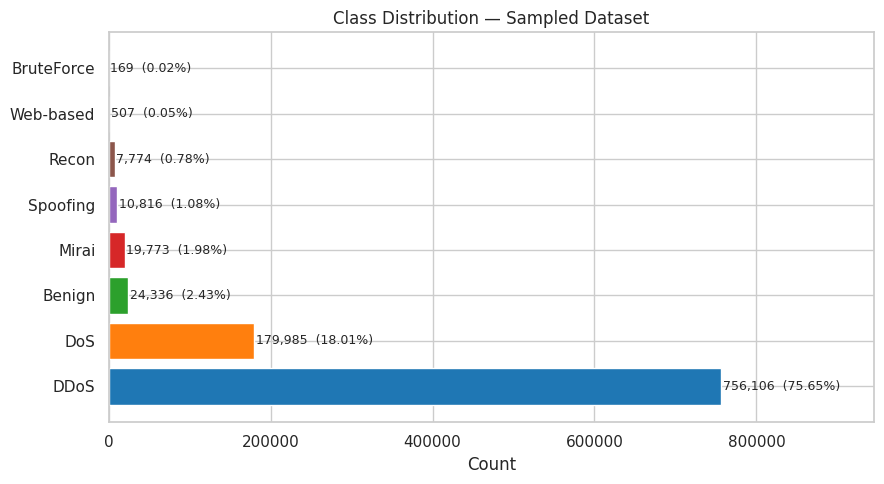

Imbalance ratio (max/min): 4474.0x

Category                Count      pct   full_dataset_pct
----------------------------------------------------------
DDoS                  756,106 75.6510%           75.6170%
DoS                   179,985 18.0081%           18.0022%
Benign                 24,336  2.4349%            2.4435%
Mirai                  19,773  1.9784%            1.9816%
Spoofing               10,816  1.0822%            1.0825%
Recon                   7,774  0.7778%            0.7889%
Web-based                 507  0.0507%            0.0552%
BruteForce                169  0.0169%            0.0291%


In [4]:
cat_counts = df['category'].value_counts()
total      = len(df)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_counts.index, cat_counts.values, color=sns.color_palette('tab10', len(cat_counts)))
for bar, (cat, n) in zip(bars, cat_counts.items()):
    pct = n / total
    ax.text(bar.get_width() + total * 0.002, bar.get_y() + bar.get_height() / 2,
            f'{n:,}  ({pct:.2%})', va='center', fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Class Distribution — Sampled Dataset')
ax.set_xlim(0, cat_counts.max() * 1.25)
plt.tight_layout()
plt.show()

imbalance_ratio = cat_counts.max() / cat_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x\n')

full_props = cfg['category_proportions']
print(f'{"Category":<18} {"Count":>10} {"pct":>8} {"full_dataset_pct":>18}')
print('-' * 58)
for cat, n in cat_counts.items():
    pct      = n / total
    full_pct = full_props.get(cat, 0.0)
    print(f'{cat:<18} {n:>10,} {pct:>8.4%} {full_pct:>18.4%}')

## §5 Feature Matrix & Label Encoding

`LabelEncoder` produces contiguous integers [0, n_classes−1] required by sklearn estimators.
The mapping is printed here and **must be kept consistent across notebooks 02–04**.
`feature_cols` excludes `label` and `category` (string columns) automatically via `select_dtypes`.

In [5]:
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(df['category'].values)

print(f'X shape    : {X.shape}')
print(f'y shape    : {y.shape}')
print(f'n_features : {X.shape[1]}')
print()
print(f'{"Class":<18} {"Index":>6}')
print('-' * 26)
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f'{cls:<18} {idx:>6}')

X shape    : (999466, 39)
y shape    : (999466,)
n_features : 39

Class               Index
--------------------------
Benign                  0
BruteForce              1
DDoS                    2
DoS                     3
Mirai                   4
Recon                   5
Spoofing                6
Web-based               7


## §6 Stratified Train / Validation / Test Split

Stratification on `y` ensures each split mirrors the full class distribution.
Without it, a random split risks zero samples of BruteForce (~0.03%) in val/test,
making per-class precision/recall undefined. The validation set is used exclusively
for Optuna hyperparameter tuning in notebook 03. The test set is not touched until
final evaluation in notebook 04.

In [6]:
# 70% train, 15% val, 15% test
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print()

full_props = cfg['category_proportions']
print(f'{"Class":<18} {"Train%":>8} {"Val%":>8} {"Test%":>8} {"Full%":>8}')
print('-' * 56)
for idx, cls in enumerate(le.classes_):
    tr_pct   = (y_train == idx).sum() / len(y_train)
    va_pct   = (y_val   == idx).sum() / len(y_val)
    te_pct   = (y_test  == idx).sum() / len(y_test)
    full_pct = full_props.get(cls, 0.0)
    print(f'{cls:<18} {tr_pct:>8.4%} {va_pct:>8.4%} {te_pct:>8.4%} {full_pct:>8.4%}')

Train : (699626, 39)
Val   : (149920, 39)
Test  : (149920, 39)

Class                Train%     Val%    Test%    Full%
--------------------------------------------------------
Benign              2.4349%  2.4346%  2.4353%  2.4435%
BruteForce          0.0169%  0.0173%  0.0167%  0.0291%
DDoS               75.6510% 75.6510% 75.6510% 75.6170%
DoS                18.0082% 18.0076% 18.0083% 18.0022%
Mirai               1.9783%  1.9784%  1.9784%  1.9816%
Recon               0.7778%  0.7777%  0.7777%  0.7889%
Spoofing            1.0821%  1.0826%  1.0819%  1.0825%
Web-based           0.0507%  0.0507%  0.0507%  0.0552%


## §7 Scaling with RobustScaler

`RobustScaler` is fit on the training set only. Fitting on val or test would leak
their distributional statistics into the scaler, invalidating held-out evaluation.
`RobustScaler` uses median and IQR instead of mean and std, making it robust to the
extreme outliers confirmed in notebook 00: `Header_Length` max ~9.8M vs median 54,
`Rate` max ~7.3M vs median ~16. `StandardScaler` would be heavily distorted by these.

In [7]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

verify_features = ['Header_Length', 'Rate', 'IAT']
verify_idx = [feature_cols.index(f) for f in verify_features if f in feature_cols]

# Reconstruct unscaled values from original X (already overwritten) — use scaler params
before_median = scaler.center_[verify_idx]
before_iqr    = scaler.scale_[verify_idx]
after_median  = np.median(X_train[:, verify_idx], axis=0)
after_iqr     = np.percentile(X_train[:, verify_idx], 75, axis=0) - \
                np.percentile(X_train[:, verify_idx], 25, axis=0)

print(f'{"Feature":<18} {"Before median":>14} {"Before IQR":>12} {"After median":>14} {"After IQR":>12}')
print('-' * 74)
for name, bm, bq, am, aq in zip(
    [feature_cols[i] for i in verify_idx],
    before_median, before_iqr, after_median, after_iqr
):
    print(f'{name:<18} {bm:>14.4f} {bq:>12.4f} {am:>14.4f} {aq:>12.4f}')

Feature             Before median   Before IQR   After median    After IQR
--------------------------------------------------------------------------
Header_Length             54.0000     703.0000         0.0000       1.0000
Rate                      16.2247     133.6210         0.0000       1.0000
IAT                 83123815.0795  264293.7438         0.0000       1.0000


## §8 Export to Parquet

Parquet over CSV: columnar compression (~5× smaller on disk), exact float64 precision
(no text rounding), and `pd.read_parquet` is substantially faster than `pd.read_csv`
for repeated loads in notebooks 02–04.

In [8]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

splits = {
    'train': (X_train, y_train),
    'val':   (X_val,   y_val),
    'test':  (X_test,  y_test),
}

print(f'{"File":<20} {"Shape":>16} {"Size MB":>10}')
print('-' * 50)
for name, (X_split, y_split) in splits.items():
    out = PROCESSED_DIR / f'{name}.parquet'
    split_df = pd.DataFrame(X_split, columns=feature_cols)
    split_df['y'] = y_split
    split_df.to_parquet(out, index=False)
    size_mb = out.stat().st_size / 1024**2
    print(f'{name + ".parquet":<20} {str(split_df.shape):>16} {size_mb:>10.1f}')

File                            Shape    Size MB
--------------------------------------------------
train.parquet            (699626, 40)       34.3
val.parquet              (149920, 40)        8.0
test.parquet             (149920, 40)        8.0


## §9 Summary

### Split sizes

| Split | Rows | % of sample |
|-------|------|-------------|
| Train | 70%  | 70%         |
| Val   | 15%  | 15%         |
| Test  | 15%  | 15%         |

### Preprocessing steps applied in this notebook

1. Load `sample_config.json` — all numeric targets sourced from script output
2. Stratified random sampling: per-file, per-class quota drawn via `DataFrame.sample()`
3. Drop constant columns (`CONSTANT_COLS`) and correlated column (`DROP_CORR_COLS`) at read time
4. Drop rows with NaN category (labels absent from `LABEL_MAP`)
5. Drop exact duplicate rows
6. Extract numeric feature matrix `X` via `select_dtypes`
7. Encode target with `LabelEncoder` → integer `y`
8. Stratified 70/15/15 split
9. `RobustScaler` fit on train, applied to val and test
10. Export `train.parquet`, `val.parquet`, `test.parquet`

### What is NOT done here

- **Imbalance mitigation** (SMOTE, class weighting, resampling) → notebook 02
- **Model training** → notebook 03
- **Final evaluation** → notebook 04